## Computing the average control and drought spectra and looking at drought response per variety

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv('/Users/zhalem/Documents/ASD_data/PANGEOS_NO_2025/csv_exports/corrected_data_all_spectra_h20removed_6only.csv')

# Metadata
classes = df['class']

# Extract plot_id + variety
df['plot_id'] = df['spectrumname'].str.extract(r'plot_(\d+)_')[0].astype(int)

variety_plots = {
    "Helmi": [1207, 1405, 1508, 1810],
    "Bjarne": [1210, 1310, 1606, 1807],
    "Demonstrant": [1108, 1304, 1601, 1807],
    "Isak": [1208, 1409, 1602, 1706],
    "Mirakel": [1402, 1504, 1707],
    "Zebra": [1103, 1305, 1502, 1701]
}

plot_to_variety = {p: v for v, plots in variety_plots.items() for p in plots}
df['variety'] = df['plot_id'].map(plot_to_variety)

# Spectral data
spectra = df.drop(columns=['class', 'spectrumname', 'plot_id', 'variety'])
spectra.columns = spectra.columns.astype(float)
wl = spectra.columns.values

# Mask H2O + noisy regions
spectra.loc[:, (wl >= 1350) & (wl <= 1460)] = np.nan
spectra.loc[:, (wl >= 1790) & (wl <= 1970)] = np.nan
spectra.loc[:, wl > 2400] = np.nan

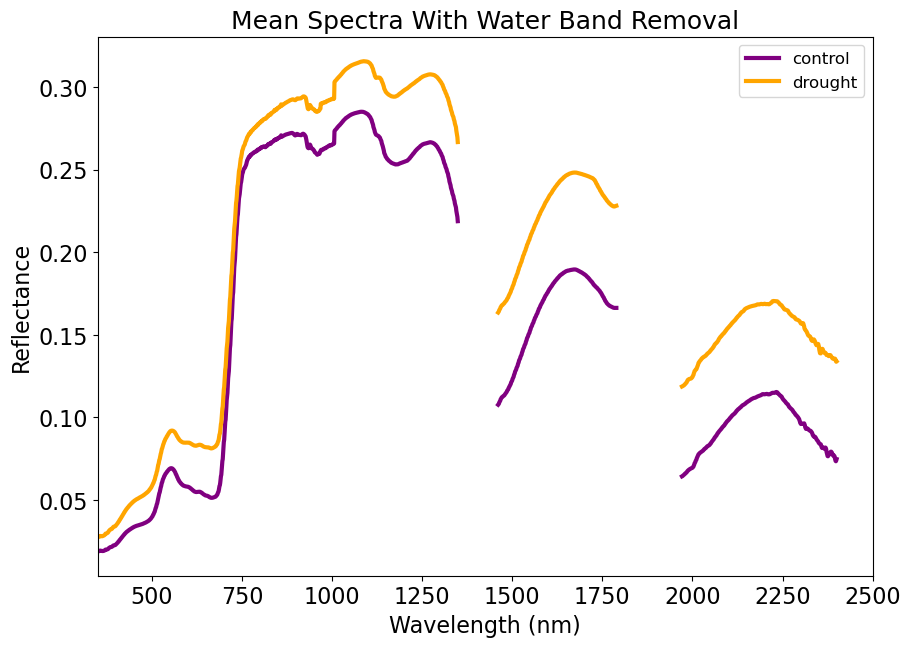

In [6]:
plt.figure(figsize=(10, 7))

for cls, color in {'control': 'purple', 'drought': 'orange'}.items():
    mean_spec = spectra[classes == cls].mean()
    plt.plot(wl, mean_spec, label=cls, color=color, linewidth=3)

plt.xlim(350, 2500)
plt.legend( fontsize=12)
plt.xlabel("Wavelength (nm)", fontsize=16)
plt.ylabel("Reflectance",  fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.title("Mean Spectra With Water Band Removal",  fontsize=18)


plt.savefig('/Users/zhalem/Documents/ASD_data/PANGEOS_NO_2025/plots/control_vs_drought_mean.png',
            dpi=300, bbox_inches='tight')
plt.show()

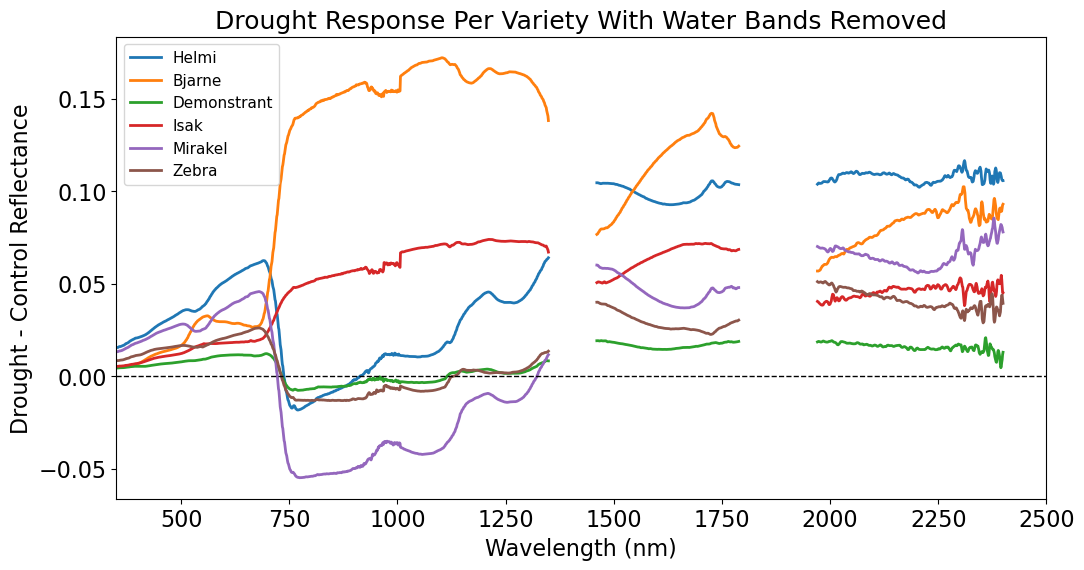

In [4]:
plt.figure(figsize=(12, 6))

for variety, plots in variety_plots.items():
    mask = df['plot_id'].isin(plots)

    subset = spectra[mask]
    subset_classes = classes[mask]

    drought_mean = subset[subset_classes == 'drought'].mean()
    control_mean = subset[subset_classes == 'control'].mean()

    diff = drought_mean - control_mean
    plt.plot(wl, diff, label=variety, linewidth=2)

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlim(350, 2500)
plt.xlabel("Wavelength (nm)", fontsize=16)
plt.ylabel("Drought - Control Reflectance", fontsize=16)
plt.title("Drought Response Per Variety With Water Bands Removed", fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.legend(fontsize=11)

plt.savefig('/Users/zhalem/Documents/ASD_data/PANGEOS_NO_2025/plots/drought_response_varieties.png',
            dpi=300, bbox_inches='tight')
plt.show()

### Plotting the first (or second) derivative spectra

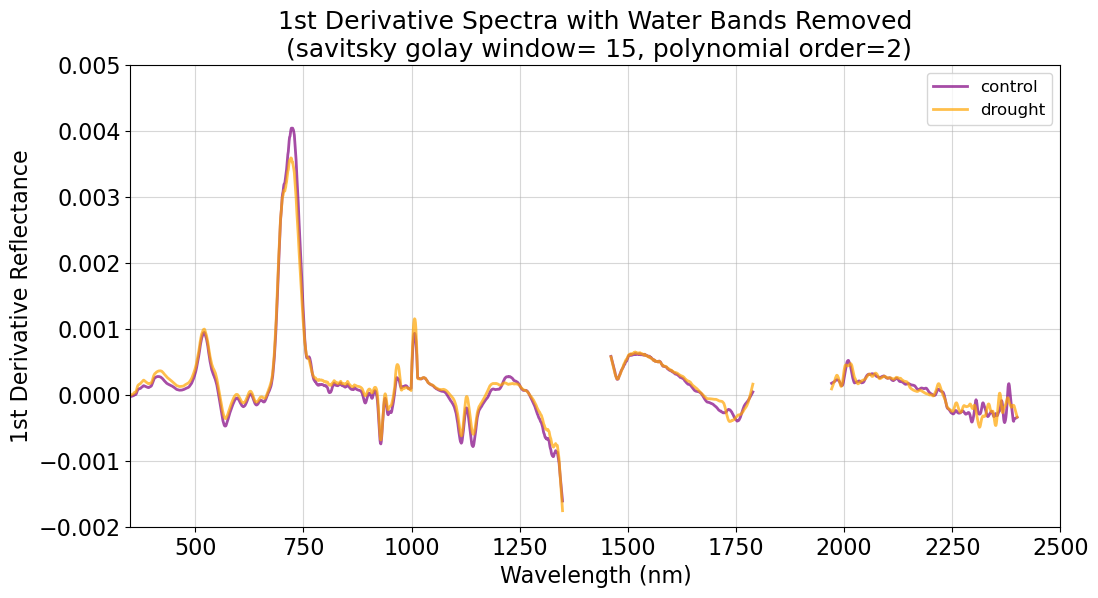

In [9]:
# swap out file path for first or second derivative
# 2dr file name: 2dr_h20removed_6only

import pandas as pd
import matplotlib.pyplot as plt

# Load averaged derivative spectra
df = pd.read_csv(
    '/Users/zhalem/Documents/ASD_data/PANGEOS_NO_2025/csv_exports/1dr_h20removed_6only.csv'
)

# Separate class labels and spectra
classes = df['class']
spectra = df.drop(columns=['class'])

# Wavelength axis
wl = spectra.columns.astype(int).values
color_map = {
    'control': 'purple',
    'drought': 'orange',
}

plt.figure(figsize=(12, 6))

for i in range(len(df)):
    cls = classes.iloc[i]
    plt.plot(wl, spectra.iloc[i].values,
             color=color_map.get(cls, 'black'),
             linewidth=2,
             alpha = 0.7,
             label=cls)

plt.xlabel("Wavelength (nm)", fontsize=16)
plt.ylabel("1st Derivative Reflectance", fontsize=16)  # change to 2nd if needed
plt.title(f"1st Derivative Spectra with Water Bands Removed\n (savitsky golay window= 15, polynomial order=2)", fontsize=18)
plt.xlim(350, 2500)
plt.ylim(-0.002, 0.005)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.legend(fontsize=12)
plt.grid(alpha=0.5)

# Save figure to a file
plt.savefig(
    '/Users/zhalem/Documents/ASD_data/PANGEOS_NO_2025/plots/1dr_spectra.png',  # file path
    dpi=300,      # resolution
    bbox_inches='tight')

plt.show()